In [15]:
print("CodeAlpha Car Price Prediction Project")
print("Student Name: Srishti Pandey")

CodeAlpha Car Price Prediction Project
Student Name: Srishti Pandey


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [17]:
from google.colab import files

uploaded = files.upload()

Saving used_cars.csv to used_cars (2).csv


In [18]:
df = pd.read_csv("used_cars.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [19]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [20]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


In [21]:
df["fuel_type"] = df["fuel_type"].fillna(df["fuel_type"].mode()[0])
df["accident"] = df["accident"].fillna("Unknown")
df["clean_title"] = df["clean_title"].fillna("Unknown")

print("Missing values handled successfully!")
print(df.isnull().sum())

Missing values handled successfully!
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


In [22]:
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
brand           object
model           object
model_year       int64
milage          object
fuel_type       object
engine          object
transmission    object
ext_col         object
int_col         object
accident        object
clean_title     object
price           object
dtype: object


In [24]:
# Convert price into numeric
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")


# Dataset uses "milage" spelling
df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["milage"] = pd.to_numeric(df["milage"], errors="coerce")

print("Price and milage converted successfully!")
print(df[["price", "milage"]].dtypes)

Price and milage converted successfully!
price     int64
milage    int64
dtype: object


In [25]:
print("Price Statistics:")
print(df["price"].describe())

Price Statistics:
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


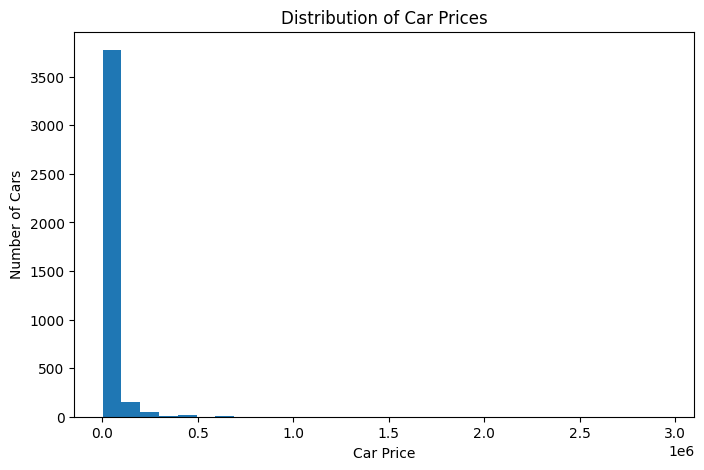

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.xlabel("Car Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Prices")

plt.show()

In [27]:
brand_price = (
    df.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 Brands by Average Price:")
print(brand_price)

Top 15 Brands by Average Price:
brand
Bugatti        1.950995e+06
Rolls-Royce    3.709927e+05
Lamborghini    2.912338e+05
Ferrari        2.437907e+05
McLaren        2.134575e+05
Maserati       1.405825e+05
Bentley        1.375535e+05
Aston          1.151996e+05
Lucid          1.019663e+05
Rivian         9.313818e+04
Porsche        8.875130e+04
Maybach        6.425000e+04
Land           5.576406e+04
Lotus          5.481250e+04
Karma          5.325000e+04
Name: price, dtype: float64


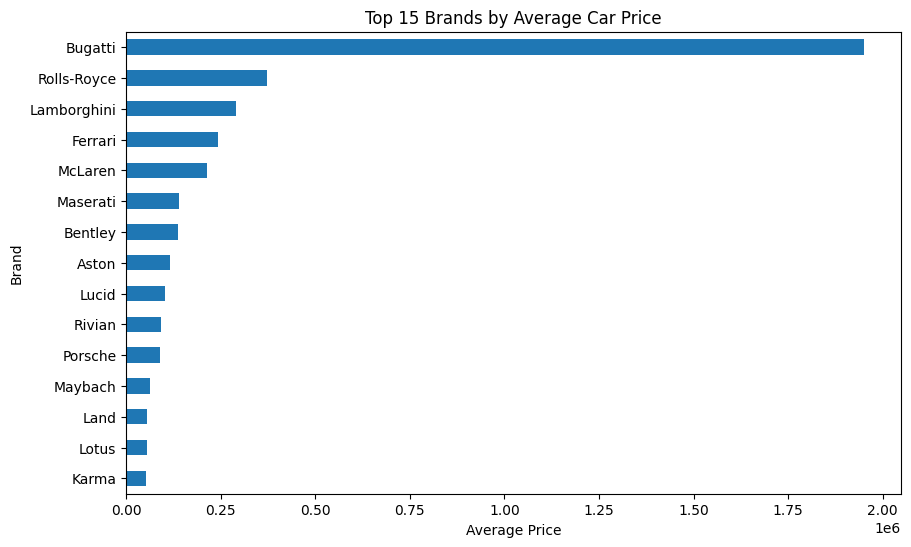

In [28]:
plt.figure(figsize=(10,6))

brand_price.sort_values().plot(kind="barh")

plt.xlabel("Average Price")
plt.ylabel("Brand")
plt.title("Top 15 Brands by Average Car Price")

plt.show()

In [29]:
current_year = 2026

df["car_age"] = current_year - df["model_year"]

df["car_age"] = df["car_age"].clip(lower=0)

print("Car age feature created successfully!")
print(df[["model_year", "car_age"]].head())

Car age feature created successfully!
   model_year  car_age
0        2013       13
1        2021        5
2        2022        4
3        2015       11
4        2021        5


In [32]:
# Fix mileage column name
if "milage" in df.columns:
    df = df.rename(columns={"milage": "mileage"})

# Clean mileage
df["mileage"] = (
    df["mileage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")[0]
)

df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")

# Clean price
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Fill missing numeric values
df["mileage"] = df["mileage"].fillna(df["mileage"].median())
df["price"] = df["price"].fillna(df["price"].median())

print("Data cleaned successfully!")
print("Mileage column exists:", "mileage" in df.columns)
print("Price column exists:", "price" in df.columns)

Data cleaned successfully!
Mileage column exists: True
Price column exists: True


In [34]:
# Select features
features = [
    "brand",
    "model",
    "model_year",
    "mileage",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title",
    "car_age"
]

# Create X and y
X = df[features]
y = df["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Features selected successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Features selected successfully!
Training data: (3207, 12)
Testing data: (802, 12)


In [35]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numeric_features)

Categorical Features:
['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

Numerical Features:
['model_year', 'mileage', 'car_age']


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()

# Create preprocessing setup
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Encoding setup completed successfully!")
print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

Encoding setup completed successfully!
Categorical features: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']
Numerical features: ['model_year', 'mileage', 'car_age']


In [38]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Training Linear Regression model...")

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression trained successfully!")

Training Linear Regression model...
Linear Regression trained successfully!


In [39]:
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2 Score:", round(linear_r2, 4))

Linear Regression Results
-------------------------
MAE : 25811.27
RMSE: 137184.62
R2 Score: 0.0793


In [40]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training Random Forest model...")

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("Random Forest trained successfully!")

Training Random Forest model...
Random Forest trained successfully!


In [41]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2 Score:", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 19010.81
RMSE: 134779.84
R2 Score: 0.1113


In [42]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

print("Model Comparison:")
display(comparison)

Model Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,25811.266846,137184.624068,0.079256
1,Random Forest,19010.807805,134779.835112,0.111253


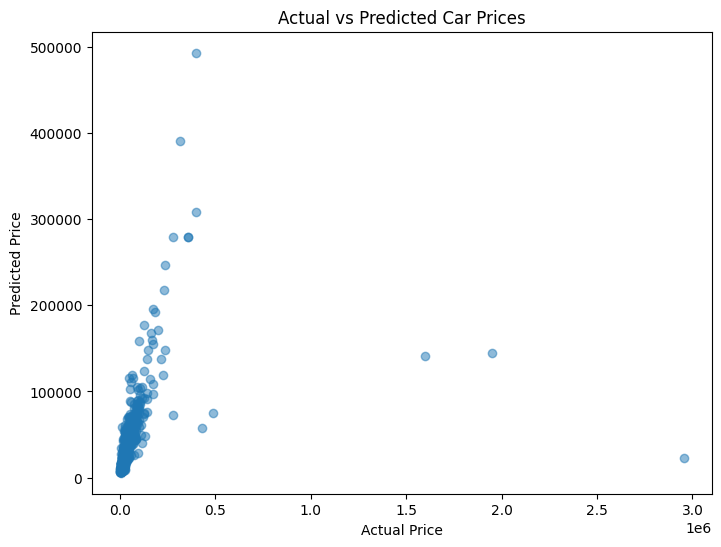

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [44]:
sample_result = X_test.copy()

sample_result["Actual Price"] = y_test.values
sample_result["Predicted Price"] = rf_pred

display(sample_result.head(10))

,brand,model,model_year,mileage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,car_age,Actual Price,Predicted Price
2580,Lexus,IS 300 Base,2018,50992,Gasoline,260.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,White,Gray,At least 1 accident or damage reported,Yes,8,28000,31969.165
3660,Chevrolet,Impala Base,2004,64500,Gasoline,180.0HP 3.4L V6 Cylinder Engine Gasoline Fuel,A/T,Beige,Beige,None reported,Yes,22,5900,15421.905
897,RAM,2500 SLT,2017,86000,Diesel,350.0HP 6.7L Straight 6 Cylinder Engine Diesel...,6-Speed A/T,Gray,Gray,At least 1 accident or damage reported,Yes,9,41000,45654.670
2091,Mercedes-Benz,SL-Class SL 550,2013,24933,Gasoline,429.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Silver,Red,At least 1 accident or damage reported,Yes,13,40250,34033.845
1044,Ford,Shelby GT350R Base,2018,18500,Gasoline,526.0HP 5.2L 8 Cylinder Engine Gasoline Fuel,M/T,Blue,Black,At least 1 accident or damage reported,Yes,8,77999,43817.350
2320,GMC,Yukon SLT,2018,85500,Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,8,35899,33040.525
465,Volvo,V60 Cross Country T5,2020,10500,Gasoline,250.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,None reported,Yes,6,36000,48231.950
196,Nissan,Titan XD SV,2020,10001,Gasoline,5.6L V8 32V GDI DOHC,9-Speed Automatic,Black,Black,None reported,Yes,6,47214,50706.685
3113,BMW,330 i,2005,59300,Gasoline,225.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,M/T,Red,Black,None reported,Yes,21,30900,18876.530
3553,Lexus,RX 330 Base,2006,110250,Gasoline,230.0HP 3.3L V6 Cylinder Engine Gasoline Fuel,A/T,White,Beige,None reported,Yes,20,11000,10201.620


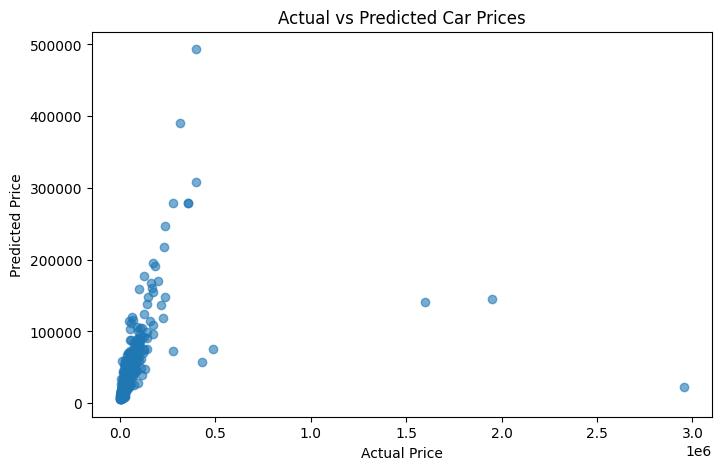

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

Feature Importance:


,Feature,Importance
3207,numeric__mileage,3.050214e-01
24,categorical__brand_Lamborghini,1.206964e-01
45,categorical__brand_Rolls-Royce,1.092162e-01
12,categorical__brand_Ferrari,4.084397e-02
306,categorical__model_Aventador SVJ Base,3.917575e-02
...,...,...
585,categorical__model_Excursion Limited 4WD,4.055603e-09
679,categorical__model_Fusion Hybrid Titanium,3.677534e-09
599,categorical__model_Explorer Eddie Bauer,2.478676e-09
900,categorical__model_M56 Base,1.791533e-09


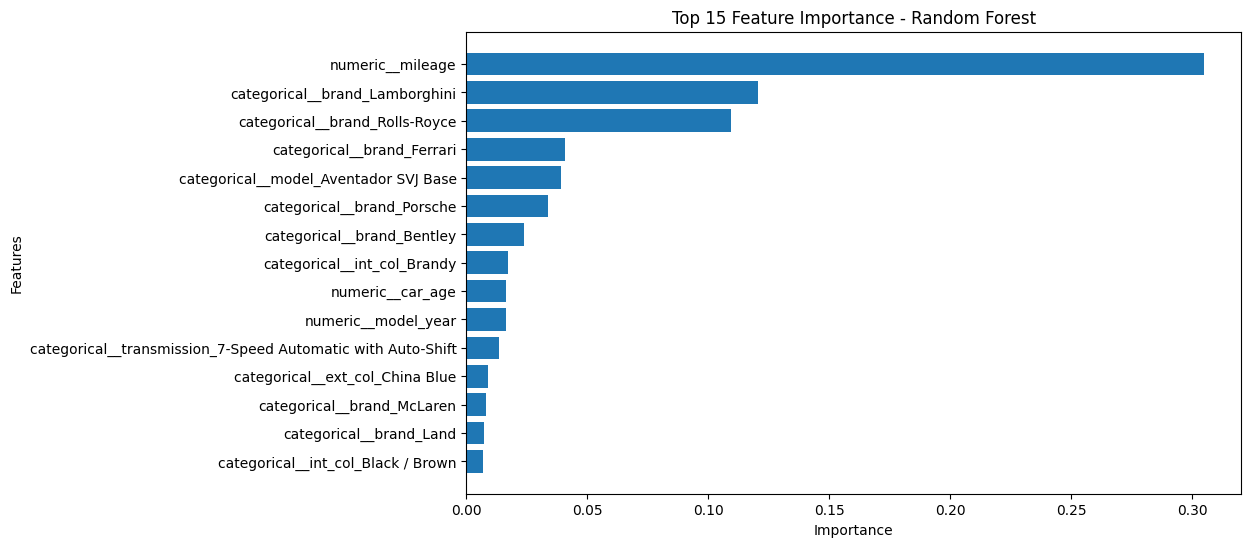

In [47]:
# Feature Importance of Random Forest

rf_model = random_forest_model.named_steps["model"]

importance = rf_model.feature_importances_

feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"].head(15),
    feature_importance["Importance"].head(15)
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Actual vs Predicted Prices:


,Actual Price,Predicted Price
0,28000,31969.165
1,5900,15421.905
2,41000,45654.670
3,40250,34033.845
4,77999,43817.350
5,35899,33040.525
6,36000,48231.950
7,47214,50706.685
8,30900,18876.530
9,11000,10201.620


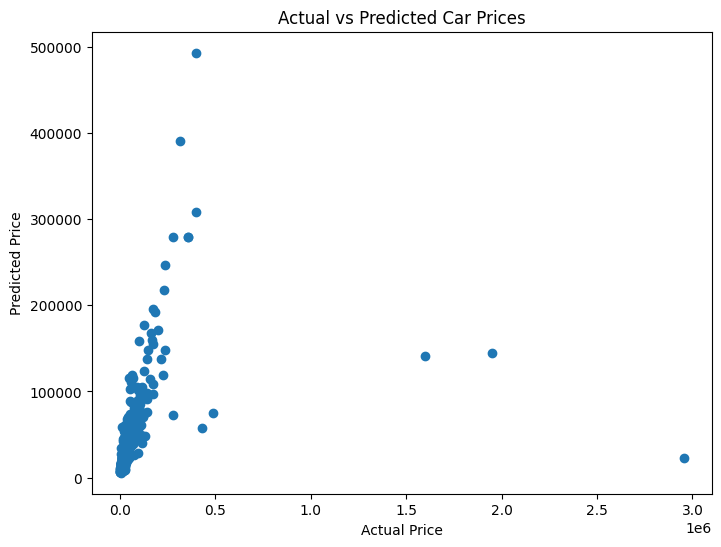

In [48]:
# Actual vs Predicted Prices

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": rf_pred
})

print("Actual vs Predicted Prices:")
display(results.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

In [49]:
print("========== CAR PRICE PREDICTION PROJECT ==========")
print()
print("Project: Used Car Price Prediction")
print("Dataset Size:", df.shape)
print()
print("Models Used:")
print("1. Linear Regression")
print("2. Random Forest Regressor")
print()
print("Best Model: Random Forest Regressor")
print("Random Forest R2 Score:", round(rf_r2, 4))
print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print()
print("Key Finding:")
print("Random Forest performed better than Linear Regression based on the model comparison.")
print("Feature importance analysis was also performed to understand the factors affecting car prices.")

========== CAR PRICE PREDICTION PROJECT ==========

Project: Used Car Price Prediction
Dataset Size: (4009, 13)

Models Used:
1. Linear Regression
2. Random Forest Regressor

Best Model: Random Forest Regressor
Random Forest R2 Score: 0.1113
Random Forest MAE: 19010.81
Random Forest RMSE: 134779.84

Key Finding:
Random Forest performed better than Linear Regression based on the model comparison.
Feature importance analysis was also performed to understand the factors affecting car prices.


## Conclusion

In this project, a machine learning model was developed to predict used car prices.

The dataset was cleaned and prepared before training the models. Linear Regression and Random Forest Regressor were used for prediction. Both models were evaluated using MAE, RMSE, and R² score.

Based on the model comparison, Random Forest Regressor performed better than Linear Regression on this dataset. Feature importance was also analyzed to understand which car features had a stronger effect on the predicted price.

This project helped in understanding data preprocessing, feature engineering, model training, model evaluation, and price prediction using Python and machine learning.